Load the imagefolders

In [1]:
import os

# Use relative paths or full Windows paths
train_dir = "train"
val_dir = "val"
test_dir = "test"

# Check if directories exist, if not print current directory contents
if os.path.exists(train_dir):
    print(os.listdir(train_dir))
else:
    print(f"Directory '{train_dir}' not found.")
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir('.')}")

['normal', 'pneumonia', 'tuberculosis']


In [2]:
# Check the structure of your data directories
import os

print("=== Directory Structure Check ===\n")

for dir_name in ["train", "val", "test"]:
    if os.path.exists(dir_name):
        print(f"\n{dir_name}/ directory contents:")
        contents = os.listdir(dir_name)
        print(f"  Items: {contents}")
        
        # Check if they are directories (class folders)
        for item in contents:
            item_path = os.path.join(dir_name, item)
            if os.path.isdir(item_path):
                num_images = len(os.listdir(item_path))
                print(f"    {item}/ -> {num_images} files")
            else:
                print(f"    {item} (file, not a folder)")
    else:
        print(f"\n{dir_name}/ directory does NOT exist")
        
print(f"\nCurrent working directory: {os.getcwd()}")

=== Directory Structure Check ===


train/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 7264 files
    pneumonia/ -> 4675 files
    tuberculosis/ -> 8514 files

val/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 900 files
    pneumonia/ -> 570 files
    tuberculosis/ -> 1064 files

test/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 925 files
    pneumonia/ -> 580 files
    tuberculosis/ -> 1064 files

Current working directory: c:\Users\Jordan Wong Jaeson\Desktop\ODL\code


Visualize an Image

Random image path: train\normal\normal-4648.jpg
Image class: normal
Image height: 512
Image width: 512
Image mode: RGB


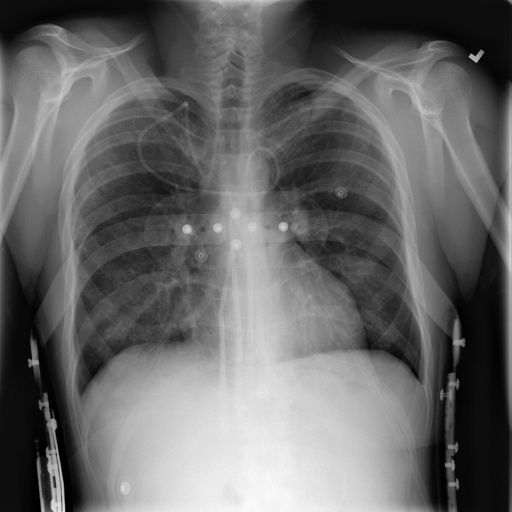

In [3]:
import os
import random
from pathlib import Path
from PIL import Image

# set seed
random.seed(42)

# Convert your original data_dir string to a path_object
base_dir = Path(train_dir)

# 1. Get all image paths 
image_path_list = list(base_dir.glob("*/*.jpg"))

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get image class from directory name
image_class = os.path.basename(os.path.dirname(random_image_path))

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
print(f"Image mode: {img.mode}")

# Display the image
img

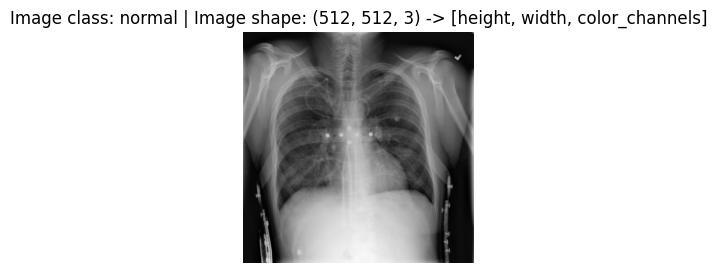

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

Transforming the image data and turn them to datasets

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Write transform for image
data_transform = transforms.Compose([
    
    # Resize the images to 224 x 224
    transforms.Resize(size=(224, 224)),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Turn the image into a torch.Tensor
    transforms.ToTensor(), # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.

])


# Use ImageFolder to create datasets

# Load full training data first (since val directory is empty)
full_train_data = datasets.ImageFolder(
    root = train_dir,
    transform = data_transform,
    target_transform = None
)

# Split training data into train (80%) and validation (20%)
from torch.utils.data import random_split

# Calculate split sizes
total_size = len(full_train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Perform the split with a fixed seed for reproducibility
train_data, val_data = random_split(
    full_train_data, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n✅ Data Split Complete:")
print(f"   Total training images: {total_size:,}")
print(f"   Training set: {train_size:,} images (80%)")
print(f"   Validation set: {val_size:,} images (20%)")

# Testing Dataset
test_data = datasets.ImageFolder(
    root = test_dir,
    transform = data_transform
)

print(f"   Test set: {len(test_data):,} images")


✅ Data Split Complete:
   Total training images: 20,453
   Training set: 16,362 images (80%)
   Validation set: 4,091 images (20%)
   Test set: 2,569 images


In [10]:
# Get class names as a list (from the full dataset before split)
class_names = full_train_data.classes
class_names

['normal', 'pneumonia', 'tuberculosis']

In [11]:
val_data

Visualize the transformed images

In [12]:
img, label = train_data[1][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.0627, 0.0627, 0.0588,  ..., 0.0431, 0.0471, 0.0471],
         [0.0549, 0.0549, 0.0627,  ..., 0.0431, 0.0431, 0.0431],
         [0.0588, 0.0588, 0.0627,  ..., 0.0431, 0.0431, 0.0431],
         ...,
         [0.0549, 0.0471, 0.0549,  ..., 0.2824, 0.2392, 0.1882],
         [0.0588, 0.0510, 0.0549,  ..., 0.2784, 0.2392, 0.1922],
         [0.0627, 0.0510, 0.0588,  ..., 0.2784, 0.2392, 0.2000]],

        [[0.0627, 0.0627, 0.0588,  ..., 0.0431, 0.0471, 0.0471],
         [0.0549, 0.0549, 0.0627,  ..., 0.0431, 0.0431, 0.0431],
         [0.0588, 0.0588, 0.0627,  ..., 0.0431, 0.0431, 0.0431],
         ...,
         [0.0549, 0.0471, 0.0549,  ..., 0.2824, 0.2392, 0.1882],
         [0.0588, 0.0510, 0.0549,  ..., 0.2784, 0.2392, 0.1922],
         [0.0627, 0.0510, 0.0588,  ..., 0.2784, 0.2392, 0.2000]],

        [[0.0627, 0.0627, 0.0588,  ..., 0.0431, 0.0471, 0.0471],
         [0.0549, 0.0549, 0.0627,  ..., 0.0431, 0.0431, 0.0431],
         [0.0588, 0.0588, 0.0627,  ..., 0.04

Original shape: torch.Size([3, 224, 224]) -> [color_channels, height, width]
Image permute shape: torch.Size([224, 224, 3]) -> [height, width, color_channels]


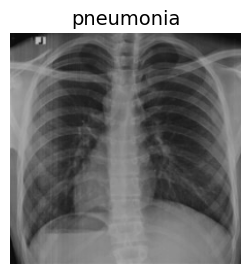

In [13]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(4, 3))
plt.imshow(img.permute(1, 2, 0),cmap="gray")
plt.axis("off")
plt.title(class_names[label], fontsize=14);

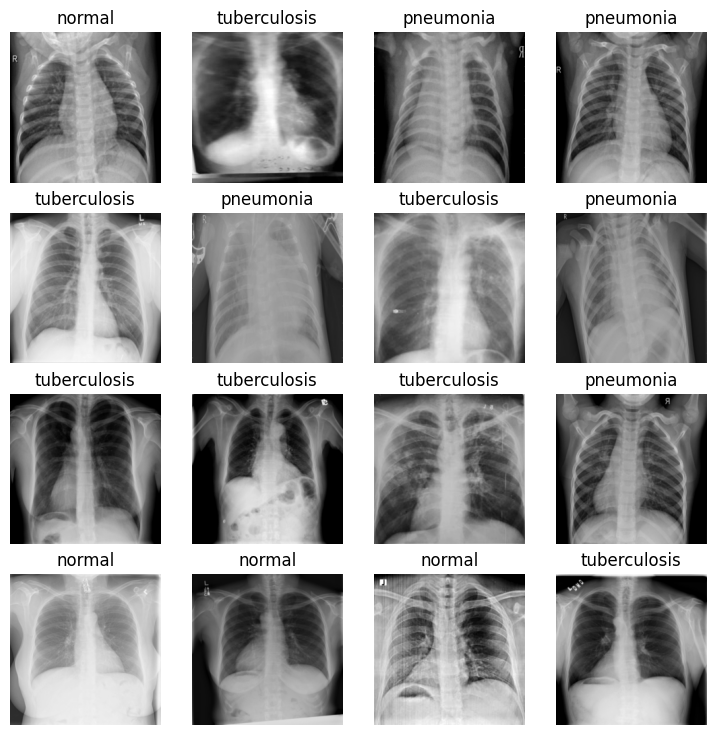

In [14]:
# plot more images
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1, 2, 0),cmap='gray') 
    plt.title(class_names[label])
    plt.axis(False)

Turn transformed images into DataLoader's

In [16]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Training DataLoader
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True,
                              pin_memory=True) # shuffle the data?

# Validation DataLoader
val_dataloader = DataLoader(dataset=val_data, 
                            batch_size=BATCH_SIZE,
                            num_workers=NUM_WORKERS,
                            pin_memory=True,
                            shuffle=False)  # Don't shuffle validation data

# Testing DataLoader
test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=BATCH_SIZE, 
                             num_workers=NUM_WORKERS, 
                             pin_memory=True,
                             shuffle=False) # don't usually need to shuffle testing data

print("DataLoaders created successfully!")
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

# Return all three DataLoaders
train_dataloader, val_dataloader, test_dataloader

Creating DataLoader's with batch size 64 and 12 workers.
DataLoaders created successfully!
Train batches: 256
Validation batches: 64
Test batches: 41


(<torch.utils.data.dataloader.DataLoader at 0x215cf91ac90>,
 <torch.utils.data.dataloader.DataLoader at 0x215cc763b90>)

In [17]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, 
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([64, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([64])


Build a model

In [18]:
import torch
import torch.nn as nn
import torchvision.models as models

# Create the pretrained EfficientNet B1 model
def create_pretrained_efficientnet_b1(num_classes, freeze_layers=True):
    """
    Create a pretrained EfficientNet B1 model for transfer learning
    
    Args:
        num_classes: Number of output classes
        freeze_layers: Whether to freeze pretrained layers (recommended for initial training)
    """
    # Load pretrained EfficientNet B1
    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V2)
    
    if freeze_layers:
        # Freeze all pretrained layers
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the final classifier
    # EfficientNet's classifier is a Sequential with: [Dropout, Linear]
    num_ftrs = model.classifier[1].in_features  # Get input features of the Linear layer
    
    # Custom classifier head (similar structure to your ResNet50 version)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    # Alternatively, for a simpler approach:
    # model.classifier = nn.Linear(num_ftrs, num_classes)
    
    return model

Create training and testing loop functions

In [19]:
# Training loop function
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

# Testing loop function
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    """Performs a testing/validation step"""
    # Put model in eval mode
    model.eval()
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # 3. Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
    
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

Main Training Function

In [20]:
%pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
from tqdm.auto import tqdm
import time

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device = device):
    """Trains and tests a PyTorch model."""
    
    # Create empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    # Make sure model is on target device
    model.to(device)
    
    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        # Training step
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer)
        
        # Testing step (optional - you might want to test less frequently)
        val_loss, val_acc = test_step(model=model,
                                       dataloader=val_dataloader,
                                       loss_fn=loss_fn)
        
        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )
        
        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
    
    # Return the filled results at the end of the epochs
    return results

c:\Users\Jordan Wong Jaeson\Desktop\ODL\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train and evaluate the model

In [23]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Create pretrained EfficientNet B1 model instance
model_0 = create_pretrained_efficientnet_b1(
    num_classes=len(class_names), 
    freeze_layers=True  # Freeze pretrained layers initially
).to(device)

print("Pretrained EfficientNet B1 model created!")
print(f"Number of classes: {len(class_names)}")

# Count trainable parameters
total_params = sum(p.numel() for p in model_0.parameters())
trainable_params = sum(p.numel() for p in model_0.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

# For transfer learning, we typically use different learning rates:
# Option 1: Only optimize the classifier (when layers are frozen)
# optimizer = torch.optim.Adam(params=model_0.classifier.parameters(), lr=0.001, weight_decay=1e-4)

# Option 2: If you want to optimize all parameters with different learning rates:
# optimizer = torch.optim.Adam([
#     {'params': model_0.classifier.parameters(), 'lr': 0.001},
#     {'params': [p for p in model_0.parameters() if p.requires_grad and not hasattr(p, 'classifier')], 'lr': 0.0001}
# ], weight_decay=1e-4)

# Option 3: SGD optimizer (often works well with pretrained models)
optimizer = torch.optim.SGD(params=model_0.classifier.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 with device parameter
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Pretrained EfficientNet B1 model created!
Number of classes: 3
Total parameters: 7,170,595
Trainable parameters: 657,411


  5%|▌         | 1/20 [02:30<47:41, 150.59s/it]

Epoch: 1 | train_loss: 1.0319 | train_acc: 0.4775 | val_loss: 0.9518 | val_acc: 0.6074


 10%|█         | 2/20 [04:36<40:46, 135.92s/it]

Epoch: 2 | train_loss: 0.8836 | train_acc: 0.6123 | val_loss: 0.7640 | val_acc: 0.7132


...

Epoch: 18 | train_loss: 0.5057 | train_acc: 0.7439 | val_loss: 0.4703 | val_acc: 0.7583


 95%|█████████▌| 19/20 [39:29<02:02, 122.27s/it]

Epoch: 19 | train_loss: 0.5008 | train_acc: 0.7481 | val_loss: 0.4662 | val_acc: 0.7713


100%|██████████| 20/20 [41:30<00:00, 124.55s/it]

Epoch: 20 | train_loss: 0.4994 | train_acc: 0.7489 | val_loss: 0.4710 | val_acc: 0.7566
Total training time: 2490.953 seconds


Loss per epoch curve

In [27]:
%pip install pandas

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   --------------

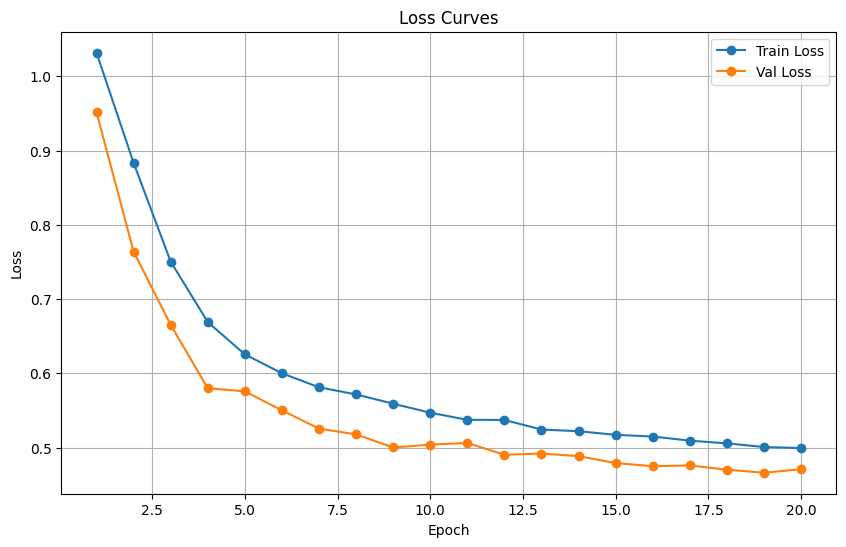

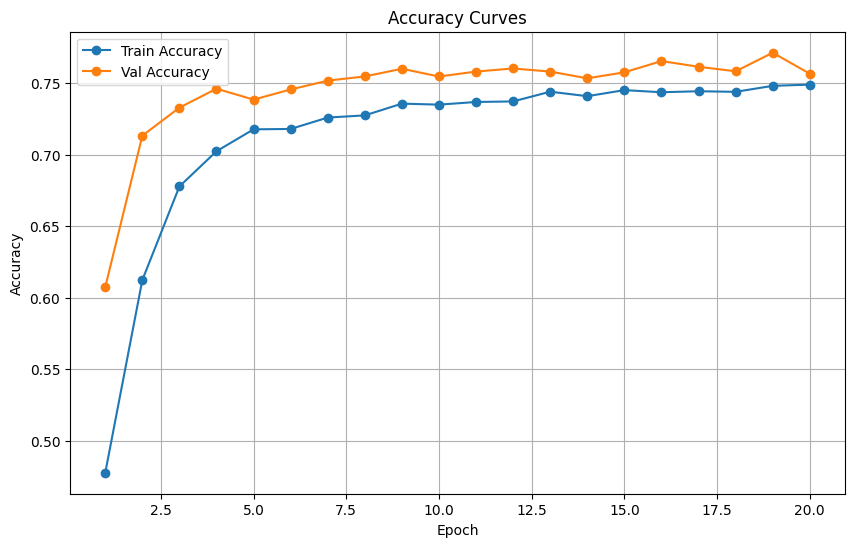

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df = pd.DataFrame(model_0_results)

epochs = list(range(1, len(df)+1))
# Plot 1: Loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, df['train_loss'], label='Train Loss',marker='o')
plt.plot(epochs, df['val_loss'], label='Val Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, df['train_acc'], label='Train Accuracy',marker='o')
plt.plot(epochs, df['val_acc'], label='Val Accuracy',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.grid(True)
plt.legend()
plt.show()

Make predictions on the test dataset

In [25]:
def predict_test_set_with_images(model, test_dataloader, class_names, num_samples=20):
    """
    Make predictions on samples from test set and return images
    """
    model.eval()
    predictions = []
    images_list = []
    samples_collected = 0
    
    with torch.inference_mode():
        for images, labels in test_dataloader:
            if samples_collected >= num_samples:
                break
               
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidences, predicted = torch.max(probabilities, 1)
           
            # Store images (move to CPU and denormalize if needed)
            images_cpu = images.cpu()
            for i in range(len(images)):
                if samples_collected >= num_samples:
                    break
                    
                predictions.append({
                    'true_label': class_names[labels[i].item()],
                    'predicted_label': class_names[predicted[i].item()],
                    'confidence': confidences[i].item(),
                    'correct': labels[i].item() == predicted[i].item()
                })
                images_list.append(images_cpu[i])
                samples_collected += 1
   
    return predictions, images_list

# Get exactly 5 predictions with images
test_predictions, test_images = predict_test_set_with_images(
    model_0, test_dataloader, class_names, num_samples=20
)

print("Test Predictions (20 samples):")
print("=" * 70)
for i, pred in enumerate(test_predictions):
    status = "✓" if pred['correct'] else "✗"
    print(f"{status} Sample {i+1}: True: {pred['true_label']:10} Predicted: {pred['predicted_label']:10} Confidence: {pred['confidence']:.4f}")

Test Predictions (20 samples):
✓ Sample 1: True: normal     Predicted: normal     Confidence: 0.7309
✓ Sample 2: True: normal     Predicted: normal     Confidence: 0.5446
✓ Sample 3: True: normal     Predicted: normal     Confidence: 0.5191
✗ Sample 4: True: normal     Predicted: tuberculosis Confidence: 0.6230
✓ Sample 5: True: normal     Predicted: normal     Confidence: 0.5760
✓ Sample 6: True: normal     Predicted: normal     Confidence: 0.5906
✓ Sample 7: True: normal     Predicted: normal     Confidence: 0.7053
✓ Sample 8: True: normal     Predicted: normal     Confidence: 0.6214
✓ Sample 9: True: normal     Predicted: normal     Confidence: 0.6791
✓ Sample 10: True: normal     Predicted: normal     Confidence: 0.7334
✓ Sample 11: True: normal     Predicted: normal     Confidence: 0.5024
✓ Sample 12: True: normal     Predicted: normal     Confidence: 0.8202
✓ Sample 13: True: normal     Predicted: normal     Confidence: 0.7088
✓ Sample 14: True: normal     Predicted: normal     C

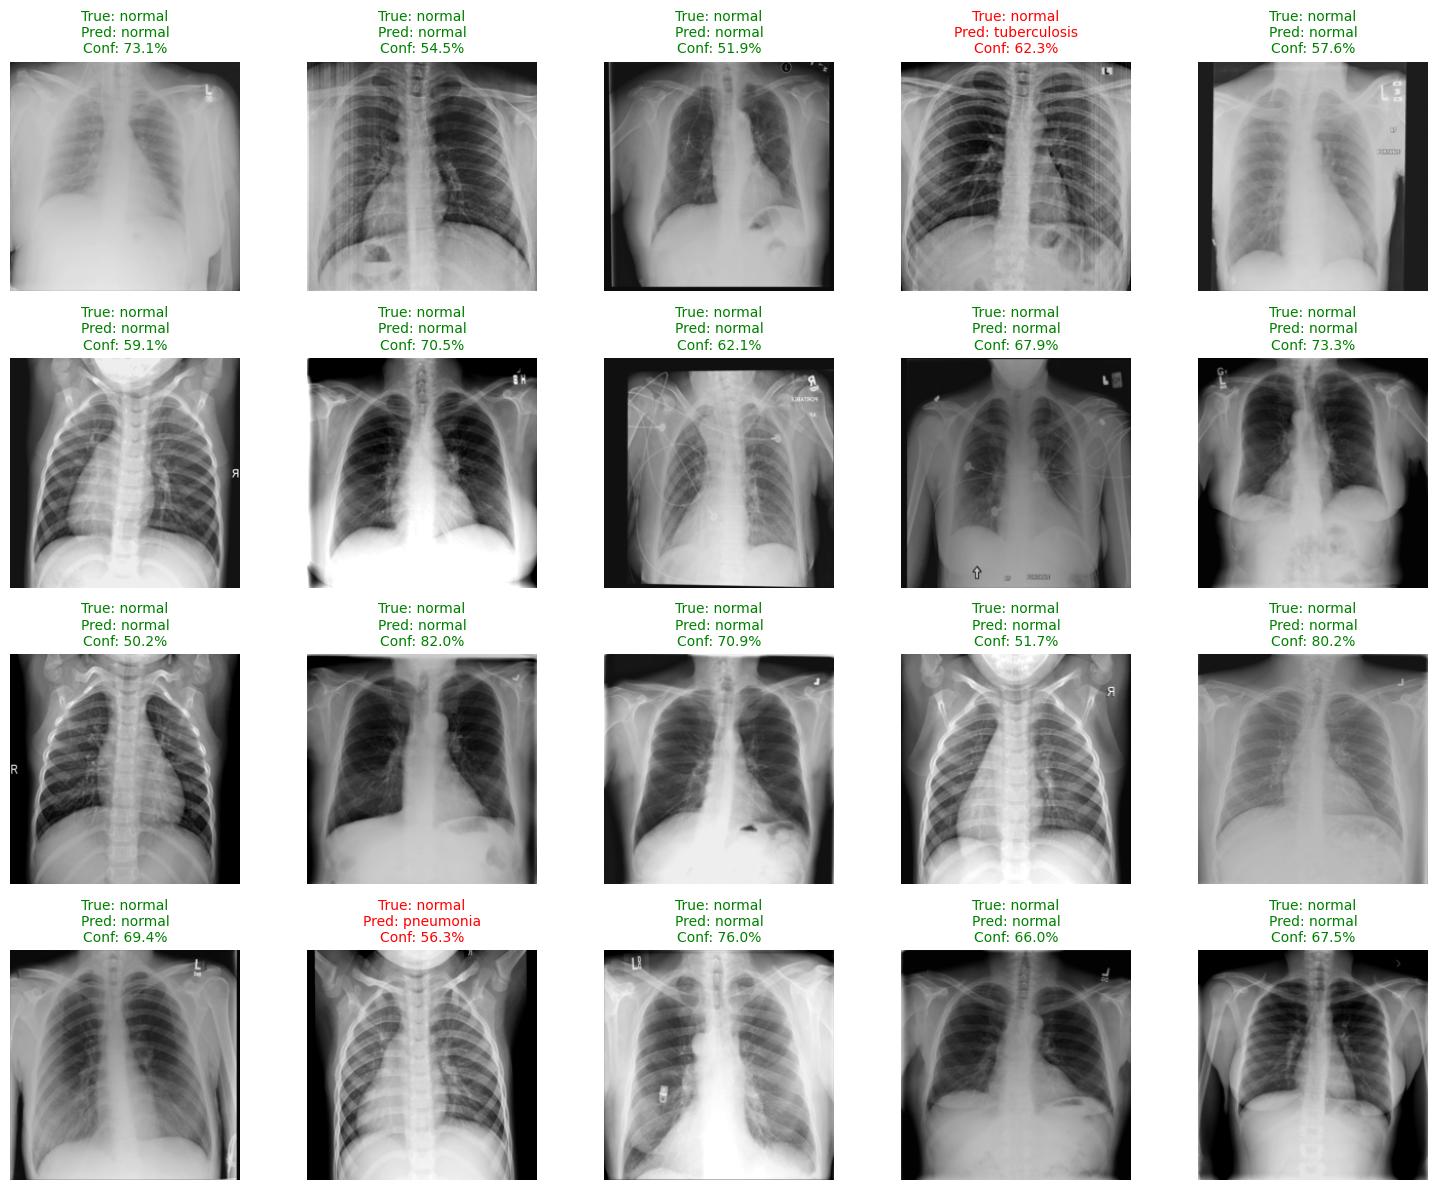

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions_grid(predictions, images, class_names, n_cols=5):
    """
    Visualize predictions in a grid with images
    """
    n_samples = len(predictions)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (pred, img) in enumerate(zip(predictions, images)):
        row = idx // n_cols
        col = idx % n_cols
        
        # Denormalize image if needed (assuming ImageNet normalization)
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        # Color code: green for correct, red for incorrect
        color = 'green' if pred['correct'] else 'red'
        confidence_percent = f"{pred['confidence']*100:.1f}%"
        
        title = f"True: {pred['true_label']}\nPred: {pred['predicted_label']}\nConf: {confidence_percent}"
        axes[row, col].set_title(title, color=color, fontsize=10)
    
    # Hide empty subplots
    for idx in range(n_samples, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage
visualize_predictions_grid(test_predictions, test_images, class_names)

Predict on Custom X-ray Image

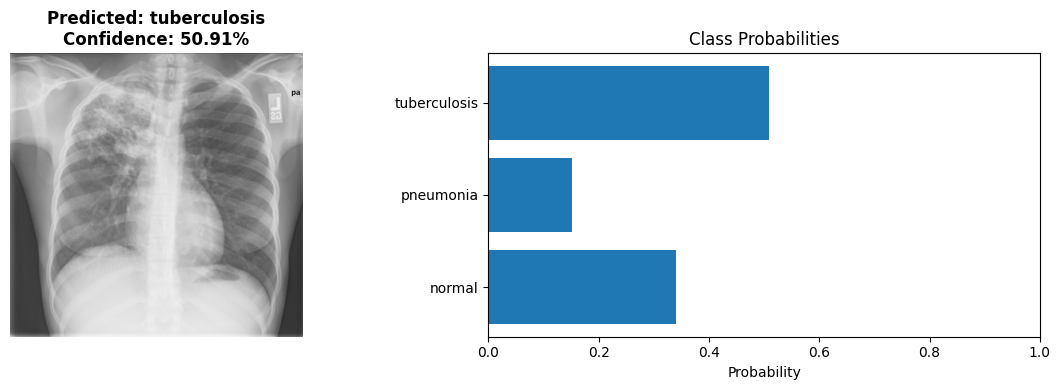


Prediction Results:
  Predicted Class: tuberculosis
  Confidence: 50.91%

All Class Probabilities:
  normal: 33.99%
  pneumonia: 15.10%
  tuberculosis: 50.91%


In [33]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_custom_image(image_path, model, transform, class_names, device):
    """
    Load and predict on a custom X-ray image
    
    Args:
        image_path: Path to your X-ray image file (e.g., "C:/path/to/xray.jpg")
        model: Trained PyTorch model
        transform: Image transformation pipeline
        class_names: List of class names
        device: Device to run prediction on
    """
    # Load the image
    img = Image.open(image_path)
    
    # Convert grayscale to RGB if necessary (X-rays are often grayscale)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Apply the same transformations used during training
    img_transformed = transform(img).unsqueeze(0)  # Add batch dimension
    
    # Move to device and make prediction
    model.eval()
    with torch.inference_mode():
        img_transformed = img_transformed.to(device)
        output = model(img_transformed)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()
    
    # Get all class probabilities
    all_probs = probabilities[0].cpu().numpy()
    
    # Display the image and prediction
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Show image
    ax1.imshow(img, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Predicted: {predicted_class}\nConfidence: {confidence_score*100:.2f}%', 
                  fontsize=12, fontweight='bold')
    
    # Show probability bar chart
    ax2.barh(class_names, all_probs)
    ax2.set_xlabel('Probability')
    ax2.set_title('Class Probabilities')
    ax2.set_xlim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPrediction Results:")
    print(f"  Predicted Class: {predicted_class}")
    print(f"  Confidence: {confidence_score*100:.2f}%")
    print(f"\nAll Class Probabilities:")
    for class_name, prob in zip(class_names, all_probs):
        print(f"  {class_name}: {prob*100:.2f}%")
    
    return predicted_class, confidence_score

# Example usage:
# Replace with your actual image path
image_path = r"C:\Users\Jordan Wong Jaeson\Desktop\ODL\code\tuberculosis.jpeg"
predicted_class, confidence = predict_custom_image(
    image_path=image_path,
    model=model_0,
    transform=data_transform,
    class_names=class_names,
    device=device
)